In [1]:
from dependencies import *
from save_data import *
from defaults import *

In [2]:
# number of runs to analyze
iters = 100_000

# read in file
iter_str = str(iters) if iters < 1000 else f"{int(iters/1000)}k"
filename = f"data/Franklin_{iter_str}.nc"

# summary stats for other thresholds
summary_stats(filename,threshold_temp=260,replace_stats=True)
summary_stats(filename,threshold_temp=270,replace_stats=True)

Stats group for 260 K already exists; deleting and remaking
Average cooling: -5.25 K
Late flag percentage: 4.33%
Early flag percentage: 2.48%
Snowball flag percentage: 1.85%


In [8]:
## copied over from 3.1_Franklin_analyze and modified

def plot_temp_density(filename,figname=None,
                      normed=False,threshold_temp=280,
                      hist=False,kdeplot=True,fill=False,
                      extra_labels=False):
    
    # for getting stats for right threshold temp
    group_name = f"stats{int(threshold_temp)}" if threshold_temp != 280 else "stats"
    
    # fetch data
    with Dataset(filename, "r") as ds:
        if not normed:
            min_T = ds.groups[group_name].variables['min_temp'][:]
        else:
            min_T = ds.groups[group_name].variables['min_normed_temp'][:]
    
    # filter out nans
    min_T = min_T[~np.isnan(min_T)]
    
    fig,ax = plt.subplots(figsize=(4,2.5))
    if hist:
        ax.hist(min_T,bins=100,density=True,color='k',alpha=0.3,histtype='step',
               label='binned data' if hist and kdeplot and extra_labels else None)
    if kdeplot:
        kde = sns.kdeplot(min_T, color='k',
                          bw_adjust=0.2 if normed else 1,
                          clip=(min_T.min(), min_T.max()),
                          label='KDE-smoothed' if hist and kdeplot and extra_labels else None)
        if fill:
            x_values = np.array(kde.get_lines()[0].get_xdata())
            y_values = np.array(kde.get_lines()[0].get_ydata())
            ax.fill_between(x_values, y_values, where=(x_values <= threshold_temp),
                            color='cadetblue', alpha=0.3)
        
    ax.set_xlim(245,305) if not normed else ax.set_xlim(-40,5)
    if threshold_temp and threshold_temp>ax.get_xlim()[0] and threshold_temp<ax.get_xlim()[1]:
        ax.axvline(threshold_temp, color='cadetblue', label='Snowball threshold_temp')
        
    ax.set_xlabel('Minimum temperature (K) within 2.15 Myr') if not normed else ax.set_xlabel('Min. temperature anomaly ($\Delta$K) within 2.15 Myr')
    ax.set_ylabel('Probability Density')
    ax.set_yticks([])
    ax.legend(loc='upper left',frameon=False)
    
    plt.tight_layout()
    if figname:
        plt.savefig(figname+'.jpg',format='jpg',bbox_inches='tight',dpi=600)
    plt.show()
    
def make_label(var_object):
    long_name = var_object.long_name
    units = var_object.units.replace("^2", "$^2$")
    label = f"{long_name} ({units})" if units else long_name
    return label

def param_density_plot(filename, param_name, threshold_temp=280,
                       ax=None, labels_on=False, label_wrap=True,
                      verbose=False):    
    with Dataset(filename, 'r') as ds:
         # for getting stats for right threshold temp
        group_name = f"stats{int(threshold_temp)}" if threshold_temp != 280 else "stats"
    
        param_data = ds.groups['params'].variables[param_name][:]
        late_flag = ds.groups[group_name].variables['late_flag'][:]
        snowball_flag = ds.groups[group_name].variables['snowball_flag'][:]
        
        try:
            x_label = make_label(ds.groups['params'].variables[param_name])
        except:
            print(f"Couldn't find metadata for {param_name}")
            x_label = param_name
            
    if verbose:
        mean_all = np.mean(param_data)
        mean_late = np.mean(param_data[late_flag == 1])
        mean_snowball = np.mean(param_data[snowball_flag == 1])
        print(f"    Mean of {param_name} (whole space): {mean_all:.4f}")
        print(f"    Mean of {param_name} (snowball any time): {mean_late:.4f}")
        print(f"    Mean of {param_name} (snowball right time): {mean_snowball:.4f}")
    
    
    ax_given = ax
    if not ax:
        fig,ax = plt.subplots(figsize=(4,2.5))
        labels_on = True
        
    labels = ['Distribution\nsampled','Snowball in\n<2.15 Myr','Snowball in\n0.9-2.15 Myr']
    if not label_wrap:
        labels = [label.replace('\n',' ') for label in labels]
    if not labels_on:
        labels = [None,None,None]
        
    sns.kdeplot(param_data, ax=ax, color='#4D4D4D',label=labels[0])
    sns.kdeplot(param_data[late_flag == 1], ax=ax, color='#8566CC',label=labels[1])
    sns.kdeplot(param_data[snowball_flag == 1], ax=ax, color='#47B3A1',label=labels[2])

    #ax.set_yticks([])
    ax.set_xlabel(x_label)
    ax.set_ylabel('Probability Density')
    if not ax_given:
        ax.legend(loc='upper center', bbox_to_anchor=(0.5,1.2), ncol=3)
    return ax

Plotting N0
    Mean of N0 (whole space): 8.2312
    Mean of N0 (snowball any time): 7.7726
    Mean of N0 (snowball right time): 9.1555
Plotting T0
    Mean of T0 (whole space): 287.7082
    Mean of T0 (snowball any time): 286.6182
    Mean of T0 (snowball right time): 286.1812
Plotting b
    Mean of b (whole space): 5.4895
    Mean of b (snowball any time): 5.5068
    Mean of b (snowball right time): 5.5046
Plotting V
    Mean of V (whole space): 8.7896
    Mean of V (snowball any time): 8.5365
    Mean of V (snowball right time): 8.5366
Plotting degass
    Mean of degass (whole space): 5.0033
    Mean of degass (snowball any time): 4.5315
    Mean of degass (snowball right time): 5.2249
Plotting A0
    Mean of A0 (whole space): 6.8050
    Mean of A0 (snowball any time): 8.2957
    Mean of A0 (snowball right time): 7.3659
Plotting B0
    Mean of B0 (whole space): 2.0553
    Mean of B0 (snowball any time): 2.3707
    Mean of B0 (snowball right time): 2.4024
Plotting emp_dur
    Mean o

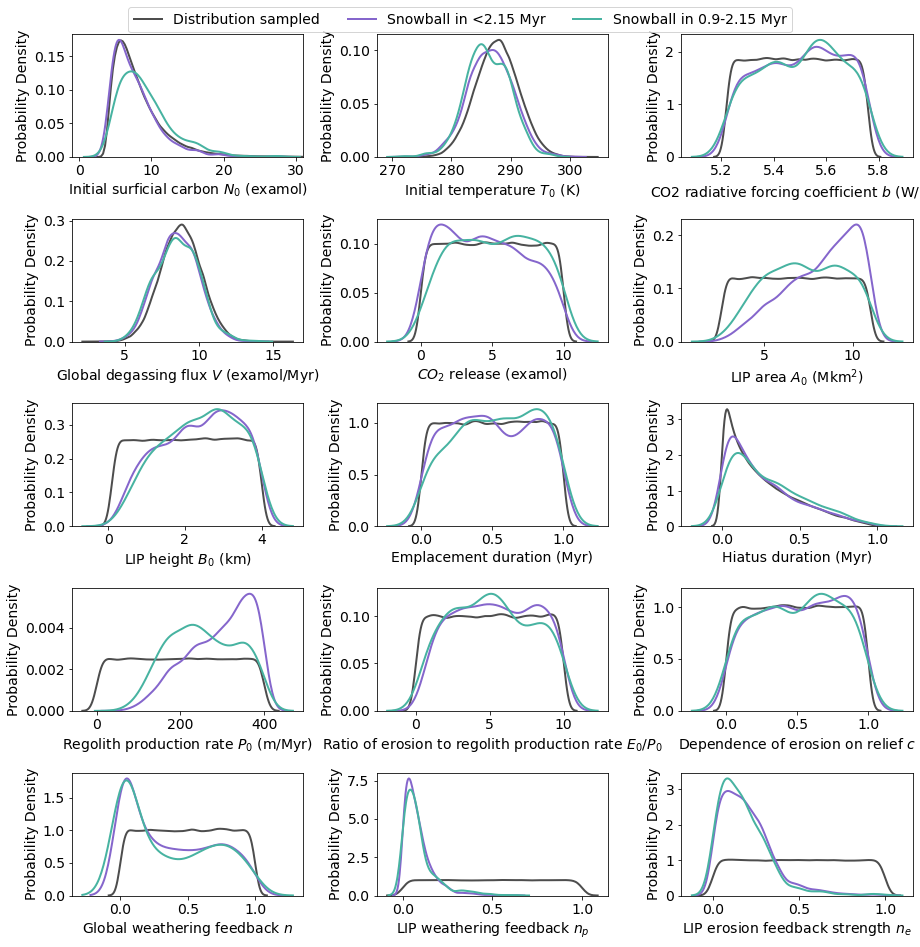

In [10]:
plt.rcParams.update({'legend.fontsize':12,
                     'font.size':14,
                     'lines.linewidth':2})

# in order to plot
param_list = ['N0','T0','b', # background climate
              'V','degass','A0', # emplacement 1
              'B0','emp_dur','erup_freq', # emplacement 2
              'P0','E_P','c', # weathering & erosion
              'n','n_p','n_e'] # feedback strengths

fig,axs = plt.subplots(5,3,figsize=(13,13))

for i in range(len(param_list)):
    ax = axs.reshape(-1)[i]
    param_name = param_list[i]
    print("Plotting",param_name)
    if param_name == 'N0':
        ax.set_xlim(-1,31)
    if i == 0:
        param_density_plot(filename=filename,threshold_temp=260,
                           param_name=param_name,ax=ax,verbose=True,
                           labels_on=True,label_wrap=False)
    else:
        param_density_plot(filename=filename,threshold_temp=260,
                           param_name=param_name,ax=ax,verbose=True)
    
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=14)

plt.tight_layout()
#plt.savefig('figs/parameters'+'.jpg',format='jpg',bbox_inches='tight',dpi=600)
plt.show()

In [50]:
def compare_thresholds_param_plot(filename, param_name, threshold_list,
                                  ax=None, labels_on=False, label_wrap=True,
                                  verbose=False):
    with Dataset(filename, 'r') as ds:
        param_data = ds.groups['params'].variables[param_name][:]
        try:
            x_label = make_label(ds.groups['params'].variables[param_name])
        except:
            print(f"Couldn't find metadata for {param_name}")
            x_label = param_name

        if verbose:
            print(f"    Mean of {param_name} (whole space): {np.mean(param_data):.4f}")

        ax_given = ax
        if not ax:
            fig, ax = plt.subplots(figsize=(4, 2.5))
            labels_on = True

        # plot full param distribution
        sns.kdeplot(param_data, ax=ax, color='#4D4D4D', label='Distribution sampled' if labels_on else None)
        
        sorted_thresholds = sorted(threshold_list, reverse=True)
        colors = sns.color_palette("PuBuGn_r", len(sorted_thresholds))

        for i, threshold in enumerate(sorted_thresholds):
            group_name = f"stats{int(threshold)}" if threshold != 280 else "stats"
            snowball_flag = ds.groups[group_name].variables['snowball_flag'][:]
            label = f"Snowball threshold = {threshold}K" if labels_on else None
            sns.kdeplot(param_data[snowball_flag == 1], ax=ax, color=colors[i], label=label)

            if verbose:
                mean_thresh = np.mean(param_data[snowball_flag == 1])
                print(f"    Mean of {param_name} (Snowball @ {threshold}K): {mean_thresh:.4f}")

        ax.set_xlabel(x_label)
        ax.set_ylabel('Probability Density')

        if not ax_given and labels_on:
            ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=1 if len(threshold_list) < 2 else len(threshold_list) + 1)

        return ax


Couldn't find metadata for n_p
    Mean of n_p (whole space): 0.4997
    Mean of n_p (Snowball @ 260K): 0.0897
    Mean of n_p (Snowball @ 270K): 0.1767
    Mean of n_p (Snowball @ 280K): 0.3817


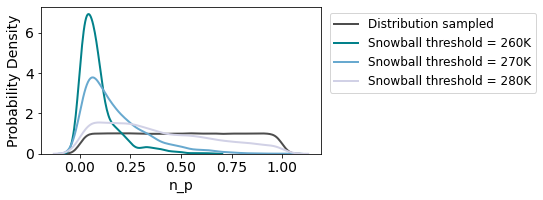

In [45]:
threshold_list=[260,270,280]

fig, ax = plt.subplots(figsize=(9, 3))
compare_thresholds_param_plot(filename=filename,
                              param_name="n_p",
                              threshold_list=threshold_list,
                              labels_on=True,
                              verbose=True,
                              ax=ax)

ax.legend(loc='upper center', bbox_to_anchor=(1.4,1), ncol=1)

plt.tight_layout()
plt.show()


Plotting N0
Couldn't find metadata for N0
    Mean of N0 (whole space): 8.2312
    Mean of N0 (Snowball @ 260K): 9.1555
    Mean of N0 (Snowball @ 270K): 8.8650
    Mean of N0 (Snowball @ 280K): 8.7135
Plotting T0
Couldn't find metadata for T0
    Mean of T0 (whole space): 287.7082
    Mean of T0 (Snowball @ 260K): 286.1812
    Mean of T0 (Snowball @ 270K): 285.5291
    Mean of T0 (Snowball @ 280K): 286.2913
Plotting b
Couldn't find metadata for b
    Mean of b (whole space): 5.4895
    Mean of b (Snowball @ 260K): 5.5046
    Mean of b (Snowball @ 270K): 5.5002
    Mean of b (Snowball @ 280K): 5.4941
Plotting V
Couldn't find metadata for V
    Mean of V (whole space): 8.7896
    Mean of V (Snowball @ 260K): 8.5366
    Mean of V (Snowball @ 270K): 8.5227
    Mean of V (Snowball @ 280K): 8.6158
Plotting degass
Couldn't find metadata for degass
    Mean of degass (whole space): 5.0033
    Mean of degass (Snowball @ 260K): 5.2249
    Mean of degass (Snowball @ 270K): 5.3130
    Mean of deg

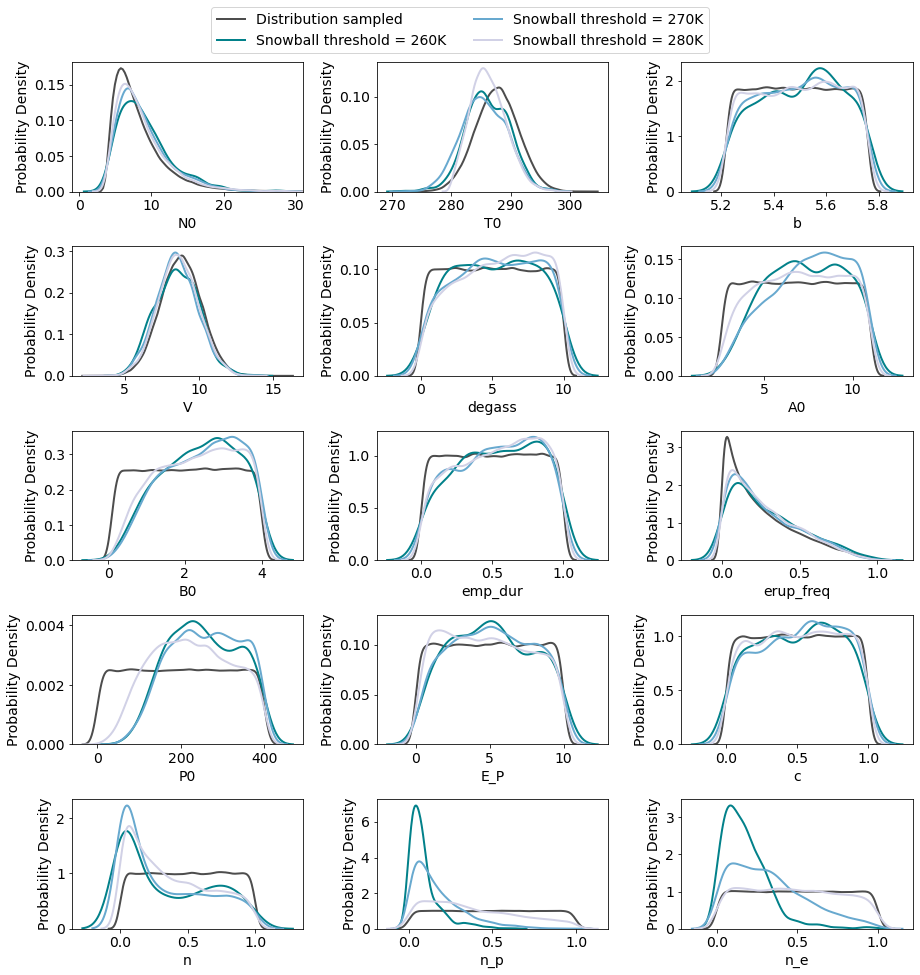

In [49]:
plt.rcParams.update({'legend.fontsize': 12,
                     'font.size': 14,
                     'lines.linewidth': 2})

param_list = ['N0', 'T0', 'b',       # background climate
              'V', 'degass', 'A0',   # emplacement 1
              'B0', 'emp_dur', 'erup_freq',  # emplacement 2
              'P0', 'E_P', 'c',      # weathering & erosion
              'n', 'n_p', 'n_e']     # feedback strengths

# Create subplot grid
fig, axs = plt.subplots(5, 3, figsize=(13, 13))

# Loop through each parameter and plot its threshold comparison
for i, param_name in enumerate(param_list):
    ax = axs.reshape(-1)[i]
    print(f"Plotting {param_name}")
    
    if param_name == 'N0':
        ax.set_xlim(-1, 31)

    compare_thresholds_param_plot(filename=filename,
                                  param_name=param_name,
                                  threshold_list=threshold_list,
                                  ax=ax,
                                  labels_on=(i == 0),  # show labels on first plot only
                                  label_wrap=False,
                                  verbose=True)

# One central legend for all
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, fontsize=14)

plt.tight_layout()
# plt.savefig('figs/compare_thresholds.jpg', format='jpg', bbox_inches='tight', dpi=600)
plt.show()
